In [1]:
from google.colab import files

uploaded = files.upload()

Saving insurance.csv.csv to insurance.csv.csv


In [2]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

In [4]:
df = pd.read_csv("insurance.csv.csv")

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
import os

os.rename("insurance.csv.csv", "insurance.csv")

In [6]:
df = pd.read_csv("insurance.csv")

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [7]:
#dataset information
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Dataset Shape: (1338, 7)

Column Names:
['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [8]:
#check missing values
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [9]:
#check duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 1


In [10]:
#descriptive statistics
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [11]:
#data cleaning
# Remove duplicate rows
df = df.drop_duplicates()

# Check missing values
print("Missing values after cleaning:")
print(df.isnull().sum())

# Check duplicate rows
print("\nDuplicate rows after cleaning:", df.duplicated().sum())

print("\nData cleaning completed!")

Missing values after cleaning:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Duplicate rows after cleaning: 0

Data cleaning completed!


In [12]:
#check data types
print(df.dtypes)

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object


## Hypothesis Testing

### Research Question
Do smokers and non-smokers have significantly different average medical insurance charges?

### Null Hypothesis (H₀)
There is no significant difference in the average medical insurance charges between smokers and non-smokers.

### Alternative Hypothesis (H₁)
There is a significant difference in the average medical insurance charges between smokers and non-smokers.

### Significance Level
α = 0.05

In [14]:
#Get Smokers and Non-Smokers Data
smoker_charges = df[df["smoker"] == "yes"]["charges"]
non_smoker_charges = df[df["smoker"] == "no"]["charges"]

print("Average charges for smokers:", smoker_charges.mean())
print("Average charges for non-smokers:", non_smoker_charges.mean())

print("\nNumber of smokers:", len(smoker_charges))
print("Number of non-smokers:", len(non_smoker_charges))

Average charges for smokers: 32050.23183153284
Average charges for non-smokers: 8440.660306508937

Number of smokers: 274
Number of non-smokers: 1063


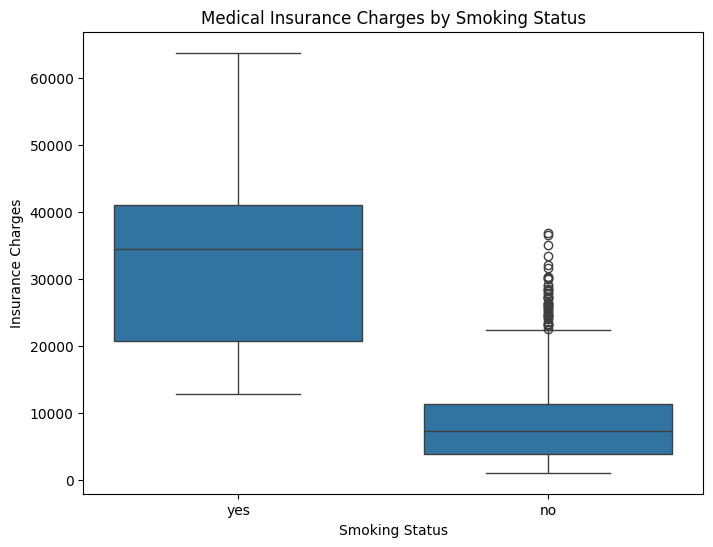

In [15]:
#Insurance Charges by Smoking Status
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="smoker",
    y="charges"
)

plt.title("Medical Insurance Charges by Smoking Status")
plt.xlabel("Smoking Status")
plt.ylabel("Insurance Charges")

plt.show()

In [16]:
#Perform Independent t-test
# Independent Samples t-test

t_statistic, p_value = stats.ttest_ind(
    smoker_charges,
    non_smoker_charges,
    equal_var=False
)

print("T-statistic:", t_statistic)
print("P-value:", p_value)

T-statistic: 32.7423097372529
P-value: 6.261720774727631e-103


In [17]:
#Interpret the Result
alpha = 0.05

if p_value < alpha:
    print("Reject the Null Hypothesis (H₀)")
    print("There is a statistically significant difference in average insurance charges between smokers and non-smokers.")
else:
    print("Fail to Reject the Null Hypothesis (H₀)")
    print("There is no statistically significant difference in average insurance charges between smokers and non-smokers.")

Reject the Null Hypothesis (H₀)
There is a statistically significant difference in average insurance charges between smokers and non-smokers.


## Independent Samples t-test Result

An independent samples t-test was performed to compare the average medical insurance charges of smokers and non-smokers.

- Significance level: α = 0.05
- If p-value < 0.05, the null hypothesis will be rejected.
- If p-value ≥ 0.05, we fail to reject the null hypothesis.

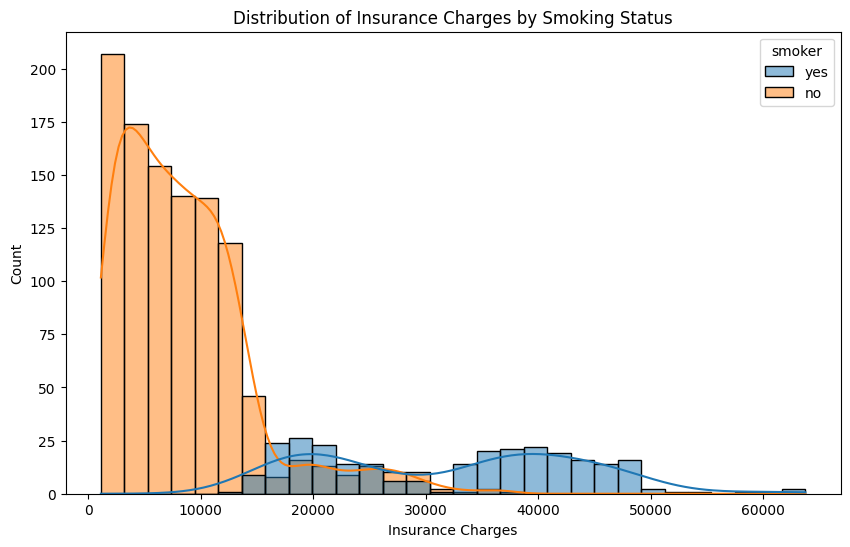

In [18]:
#Distribution of Charges
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="charges",
    hue="smoker",
    kde=True,
    bins=30
)

plt.title("Distribution of Insurance Charges by Smoking Status")
plt.xlabel("Insurance Charges")
plt.ylabel("Count")

plt.show()

In [19]:
#Get Charges for Each Region
# Separate insurance charges by region

southwest = df[df["region"] == "southwest"]["charges"]
southeast = df[df["region"] == "southeast"]["charges"]
northwest = df[df["region"] == "northwest"]["charges"]
northeast = df[df["region"] == "northeast"]["charges"]

print("Southwest average:", southwest.mean())
print("Southeast average:", southeast.mean())
print("Northwest average:", northwest.mean())
print("Northeast average:", northeast.mean())

Southwest average: 12346.937377292308
Southeast average: 14735.411437609888
Northwest average: 12450.840843950617
Northeast average: 13406.384516385804


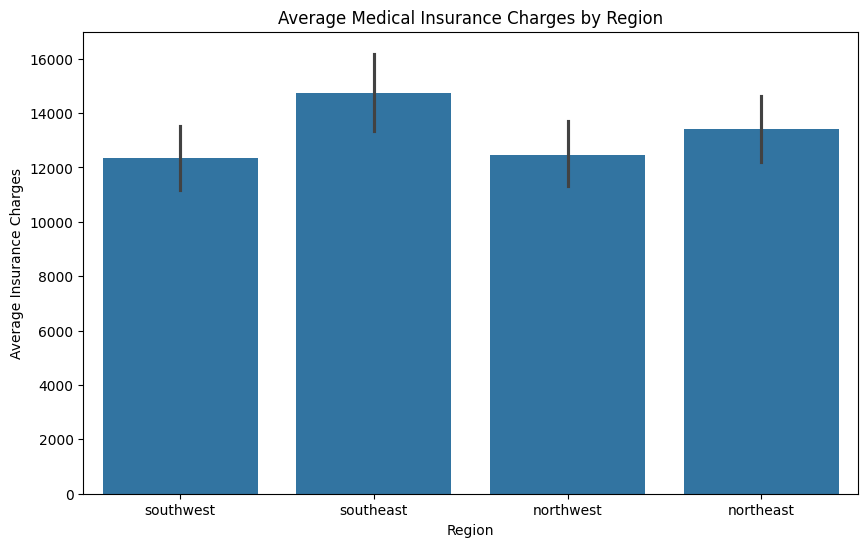

In [20]:
#Average Insurance Charges by Region
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df,
    x="region",
    y="charges"
)

plt.title("Average Medical Insurance Charges by Region")
plt.xlabel("Region")
plt.ylabel("Average Insurance Charges")

plt.show()

In [22]:
# One-Way ANOVA

f_statistic, p_value_anova = stats.f_oneway(
    southwest,
    southeast,
    northwest,
    northeast
)

print("F-statistic:", f_statistic)
print("P-value:", p_value_anova)

F-statistic: 2.9261399036627767
P-value: 0.03276288025444947


In [23]:
#nterpret ANOVA Result
alpha = 0.05

if p_value_anova < alpha:
    print("Reject the Null Hypothesis (H₀)")
    print("There is a statistically significant difference in average insurance charges among the regions.")
else:
    print("Fail to Reject the Null Hypothesis (H₀)")
    print("There is no statistically significant difference in average insurance charges among the regions.")

Reject the Null Hypothesis (H₀)
There is a statistically significant difference in average insurance charges among the regions.


In [24]:
# Create contingency table

contingency_table = pd.crosstab(df["sex"], df["smoker"])

print(contingency_table)

smoker   no  yes
sex             
female  547  115
male    516  159


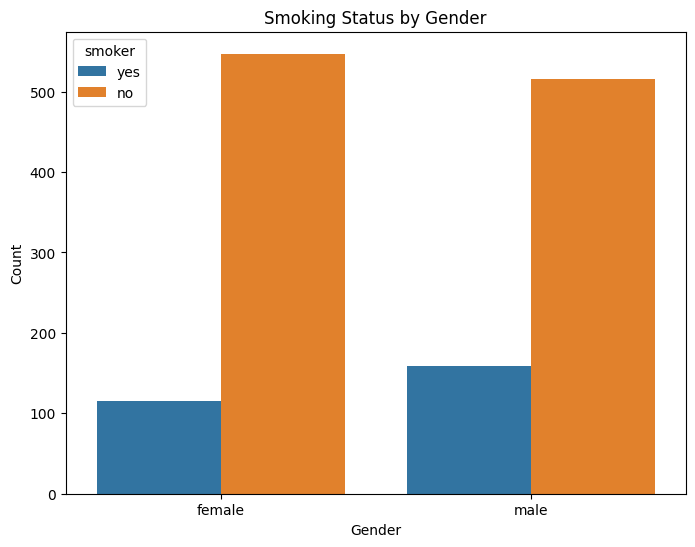

In [25]:
#Visualize Gender vs Smoking Status
plt.figure(figsize=(8, 6))

sns.countplot(
    data=df,
    x="sex",
    hue="smoker"
)

plt.title("Smoking Status by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

In [26]:
#Perform Chi-Square Test
chi2, p_value_chi, dof, expected = stats.chi2_contingency(
    contingency_table
)

print("Chi-square statistic:", chi2)
print("P-value:", p_value_chi)
print("Degrees of freedom:", dof)

Chi-square statistic: 7.469139330086637
P-value: 0.0062765550120107375
Degrees of freedom: 1


In [27]:
#interpret the Result
alpha = 0.05

if p_value_chi < alpha:
    print("Reject the Null Hypothesis (H₀)")
    print("There is a statistically significant association between gender and smoking status.")
else:
    print("Fail to Reject the Null Hypothesis (H₀)")
    print("There is no statistically significant association between gender and smoking status.")

Reject the Null Hypothesis (H₀)
There is a statistically significant association between gender and smoking status.


In [28]:
# Calculate 95% Confidence Interval for mean insurance charges

mean_charges = df["charges"].mean()

standard_error = stats.sem(df["charges"])

confidence_interval = stats.t.interval(
    0.95,
    len(df["charges"]) - 1,
    loc=mean_charges,
    scale=standard_error
)

print("Mean Insurance Charges:", mean_charges)
print("95% Confidence Interval:", confidence_interval)

Mean Insurance Charges: 13279.121486655948
95% Confidence Interval: (np.float64(12629.391284827158), np.float64(13928.851688484738))


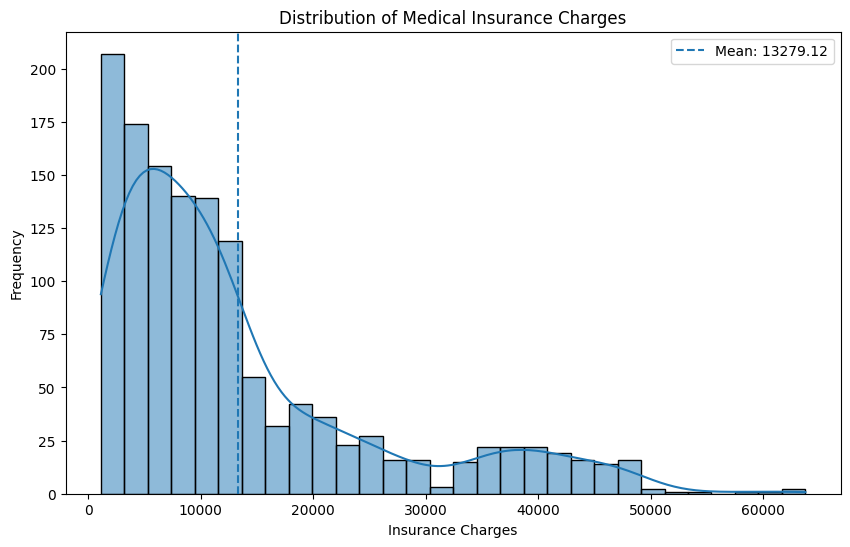

In [29]:
#Visualize Insurance Charges Distribution
plt.figure(figsize=(10, 6))

sns.histplot(
    df["charges"],
    bins=30,
    kde=True
)

plt.axvline(
    mean_charges,
    linestyle="--",
    label=f"Mean: {mean_charges:.2f}"
)

plt.title("Distribution of Medical Insurance Charges")
plt.xlabel("Insurance Charges")
plt.ylabel("Frequency")

plt.legend()

plt.show()

In [31]:
#Final Summary of Statistical Tests
print("----- STATISTICAL ANALYSIS SUMMARY -----")

print("\n1. Independent Samples t-test")
print(f"T-statistic: {t_statistic:.4f}")
print(f"P-value: {p_value:.10f}")

print("\n2. One-Way ANOVA")
print(f"F-statistic: {f_statistic:.4f}")
print(f"P-value: {p_value_anova:.10f}")

print("\n3. Chi-Square Test")
print(f"Chi-square statistic: {chi2:.4f}")
print(f"P-value: {p_value_chi:.10f}")

print("\n4. 95% Confidence Interval")
print(f"Mean insurance charges: {mean_charges:.2f}")
print(f"Confidence Interval: ({confidence_interval[0]:.2f}, {confidence_interval[1]:.2f})")

----- STATISTICAL ANALYSIS SUMMARY -----

1. Independent Samples t-test
T-statistic: 32.7423
P-value: 0.0000000000

2. One-Way ANOVA
F-statistic: 2.9261
P-value: 0.0327628803

3. Chi-Square Test
Chi-square statistic: 7.4691
P-value: 0.0062765550

4. 95% Confidence Interval
Mean insurance charges: 13279.12
Confidence Interval: (12629.39, 13928.85)
